# Creator Policy Impact Simulator — Notebook 1: Data Cleaning & Feature Engineering
**Dataset:** YouTube Trending Videos Dataset (Kaggle)  

---
## What this project is about

The YouTube Partner Program (YPP) sets eligibility thresholds that decide which creators can monetize their content. When YouTube changes a policy — tightening or loosening these thresholds — thousands of creators gain or lose monetization status overnight.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

**Dataset:** YouTube Trending Videos Dataset  
**Download:** https://www.kaggle.com/datasets/datasnaek/youtube-new  
 `USvideos.csv` and `US_category_id.json` in `../data/raw/`

**What it contains:** Trending video metadata — views, likes, dislikes, comment count, channel name, category, publish date, trending date.

In [2]:
# Loading raw data
df = pd.read_csv('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/data/raw/USvideos.csv', encoding='utf-8-sig')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nDate range: {df["trending_date"].min()} to {df["trending_date"].max()}')
print(f'Unique channels: {df["channel_title"].nunique():,}')
print(f'Unique videos: {df["video_id"].nunique():,}')
df.head(3)

Shape: (35349, 16)

Columns: ['video_id', 'trending_date', 'title', 'channel_title', 'category_id', 'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'video_error_or_removed', 'description']

Date range: 17.01.12 to 18.31.03
Unique channels: 2,153
Unique videos: 5,967


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...


In [3]:
# Checking missing values
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0])

Missing values:
description    505
dtype: int64


## 2. Data Cleaning

In [4]:
# Standardizing column names
df.columns = df.columns.str.lower().str.replace(' ', '_').str.strip()

# Parse dates
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m', errors='coerce')
df['publish_time']  = pd.to_datetime(df['publish_time'], errors='coerce', utc=True)

# Numeric columns
for col in ['views', 'likes', 'dislikes', 'comment_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Boolean flags
if 'comments_disabled' in df.columns:
    df['comments_disabled'] = df['comments_disabled'].astype(str).str.lower().str.strip() == 'true'
if 'ratings_disabled' in df.columns:
    df['ratings_disabled']  = df['ratings_disabled'].astype(str).str.lower().str.strip() == 'true'

# Clean text fields
df['channel_title'] = df['channel_title'].fillna('Unknown').str.strip()
df['title']         = df['title'].fillna('').str.strip()
df['tags']          = df['tags'].fillna('[none]')

# Remove exact duplicates
df = df.drop_duplicates(subset=['video_id', 'trending_date'])

print(f'Clean shape: {df.shape}')
print('Cleaning done.')

Clean shape: (35299, 16)
Cleaning done.


In [5]:
df.tail(10)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
35339,lD1mPectYOM,2018-05-17,"Town of Reston: “Small Town, Big Mystery” - Im...",Impulse,24,2018-04-25 17:00:03+00:00,"Impulse|""Impulse Series""|""Drama""|""Science Fict...",735962,7788,883,626,https://i.ytimg.com/vi/lD1mPectYOM/default.jpg,False,False,False,"In the small town of Reston, NY, things aren’t..."
35340,qOioqgPyCwE,2018-05-17,Adam and Jenna's Cha Cha – Dancing with the Stars,Dancing With The Stars,24,2018-05-01 04:09:17+00:00,"abc|""dancing""|""with""|""the""|""stars""|""dwts""|""Sis...",1121649,12888,632,999,https://i.ytimg.com/vi/qOioqgPyCwE/default.jpg,False,False,False,Adam Rippon and Jenna Johnson dance the Cha Ch...
35341,8bNu6Ktj858,2018-05-17,Cardi B Sued for $10 Million,The Wendy Williams Show,24,2018-04-30 21:00:01+00:00,"cardi b|""blake shelton""|""miranda lambert""|""nin...",619443,6665,1158,1171,https://i.ytimg.com/vi/8bNu6Ktj858/default.jpg,False,False,False,Cardi B's ex-manager is suing her for $10 mill...
35342,0zMSMJZc9EA,2018-05-17,Historical Misconceptions For You to Bring Up ...,Sam O'Nella Academy,22,2018-04-30 17:20:18+00:00,[none],1116764,54358,1142,4758,https://i.ytimg.com/vi/0zMSMJZc9EA/default.jpg,False,False,False,Get two months of Skillshare Premium for free ...
35343,tpa4kp4lK60,2018-05-17,I have a brain tumor.,Simone Giertz,28,2018-04-30 15:28:50+00:00,[none],2865758,248715,3720,48389,https://i.ytimg.com/vi/tpa4kp4lK60/default.jpg,False,False,False,Curve ball from life! Everything still feels p...
35344,qSKOPBVkpJk,2018-05-17,Tom Hiddleston's spot-on Korg impression.,BBC Radio 1,10,2018-04-30 12:42:40+00:00,"infinity war|""marvel""|""tom hiddleston""|""sebast...",2679999,52151,949,1805,https://i.ytimg.com/vi/qSKOPBVkpJk/default.jpg,False,False,False,"Avengers: Infinity War stars Tom Hiddleston, L..."
35345,ssk48FCVolk,2018-05-17,Drop the Mic: Seth Rogen vs Joseph Gordon-Levi...,TBS,24,2018-04-30 05:59:48+00:00,"TBS|""TBS Network""|""Comedy""|""TBS Shows""|""Shows""...",1356734,17910,376,841,https://i.ytimg.com/vi/ssk48FCVolk/default.jpg,False,False,False,Two pals put their friendship on the line when...
35346,13xFL17XmYU,2018-05-17,Little Kid Runs in Slow Motion During Baseball...,RM Videos,24,2018-04-30 18:57:01+00:00,[none],310140,1521,246,474,https://i.ytimg.com/vi/13xFL17XmYU/default.jpg,False,False,False,For licensing/usage please contact: licensing(...
35347,Kw0ih4jPOBo,2018-05-17,Kacey Musgraves - Space Cowboy (Official Music...,KaceyMusgravesVEVO,10,2018-04-30 09:00:01+00:00,"Kacey|""Musgraves""|""Space""|""Cowboy""|""MCA""|""Nash...",920289,9754,658,552,https://i.ytimg.com/vi/Kw0ih4jPOBo/default.jpg,False,False,False,"Listen to the new Kacey Musgraves album, Golde..."
35348,Es9CfWMmPRU,2018-05-17,$120 McGriddle Taste Test | FANCY FAST FOOD,Good Mythical Morning,24,2018-04-30 10:22:13+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",1259565,21892,844,2749,https://i.ytimg.com/vi/Es9CfWMmPRU/default.jpg,False,False,False,Is our $120 McGriddle a McMasterpiece or a McD...


## 3. Create the Creator-Level Dataset

The raw data is at the video level — one row per video per trending day.  
We need to aggregate to the **channel level** to simulate creator eligibility.  
Each row in the final dataset = one creator (channel).

In [6]:
# Aggregate to channel level
creators = df.groupby('channel_title').agg(
    total_videos        = ('video_id',       'nunique'),
    total_views         = ('views',          'sum'),
    avg_views_per_video = ('views',          'mean'),
    total_likes         = ('likes',          'sum'),
    total_dislikes      = ('dislikes',       'sum'),
    total_comments      = ('comment_count',  'sum'),
    avg_likes           = ('likes',          'mean'),
    avg_comments        = ('comment_count',  'mean'),
    trending_days       = ('trending_date',  'nunique'),
    first_trending      = ('trending_date',  'min'),
    last_trending       = ('trending_date',  'max'),
    comments_disabled_pct = ('comments_disabled', 'mean'),
    ratings_disabled_pct  = ('ratings_disabled',  'mean'),
    unique_categories   = ('category_id',    'nunique'),
).reset_index()

# Channel tenure (days from first to last trending)
creators['channel_tenure_days'] = (
    creators['last_trending'] - creators['first_trending']
).dt.days.fillna(0)

# Most common category per channel
top_cat = df.groupby('channel_title')['category_id'].agg(
    lambda x: x.mode()[0] if len(x) > 0 else 0
).reset_index()
top_cat.columns = ['channel_title', 'primary_category_id']
creators = creators.merge(top_cat, on='channel_title', how='left')

print(f'Creator dataset: {creators.shape}')
print(f'Unique creators: {len(creators):,}')
creators.tail(10)

Creator dataset: (2153, 17)
Unique creators: 2,153


,channel_title,total_videos,total_views,avg_views_per_video,total_likes,total_dislikes,total_comments,avg_likes,avg_comments,trending_days,first_trending,last_trending,comments_disabled_pct,ratings_disabled_pct,unique_categories,channel_tenure_days,primary_category_id
2143,yovo68,1,684547,342273.5000,7282,345,3959,3641.0000,1979.5000,2,2018-01-08,2018-01-09,0.0000,0.0000,1,1,2
2144,zefrank1,2,25233698,1146986.2727,1973037,21214,261211,89683.5000,11873.2273,22,2018-04-26,2018-05-17,0.0000,0.0000,1,21,22
2145,Алексей Навальный,1,5579079,5579079.0000,365439,63579,77462,365439.0000,77462.0000,1,2018-02-17,2018-02-17,0.0000,0.0000,1,0,29
2146,Никита Ордынский,1,18578173,1429090.2308,1747132,13411,103133,134394.7692,7933.3077,13,2018-02-25,2018-03-09,0.0000,0.0000,1,12,1
2147,ТСН,1,180711,180711.0000,1667,418,1082,1667.0000,1082.0000,1,2017-11-30,2017-11-30,0.0000,0.0000,1,0,25
2148,ワーナー ブラザース 公式チャンネル,1,7389323,1231553.8333,154962,6128,21560,25827.0000,3593.3333,6,2017-12-03,2017-12-08,0.0000,0.0000,1,5,1
2149,圧倒的不審者の極み!,1,11417717,951476.4167,157447,12315,54177,13120.5833,4514.7500,12,2018-03-05,2018-03-16,0.0000,0.0000,1,11,28
2150,杰威爾音樂 JVR Music,1,10146057,3382019.0000,198988,7981,22960,66329.3333,7653.3333,3,2018-05-15,2018-05-17,0.0000,0.0000,1,2,10
2151,郭韋辰,1,26964,13482.0000,99,2,8,49.5000,4.0000,2,2017-12-07,2017-12-08,0.0000,0.0000,1,1,28
2152,영국남자 Korean Englishman,1,5963784,993964.0000,147154,2579,16590,24525.6667,2765.0000,6,2018-01-04,2018-01-09,0.0000,0.0000,1,5,23


## 4. Feature Engineering — The Policy-Relevant Signals

**T&S insight:** YPP eligibility is not just about raw view counts. The team looks at *quality signals* — engagement rate, consistency, content health indicators. We engineer features that proxy these dimensions.

In [7]:
# ── ENGAGEMENT QUALITY FEATURES ──────────────────────────────────────────

# Like rate: likes / views — measures content quality signal
creators['like_rate'] = (
    creators['total_likes'] / creators['total_views'].replace(0, 1)
).clip(upper=1)

# Comment rate: comments / views — measures community engagement
creators['comment_rate'] = (
    creators['total_comments'] / creators['total_views'].replace(0, 1)
).clip(upper=0.5)

# Overall engagement rate: (likes + comments) / views
creators['engagement_rate'] = (
    (creators['total_likes'] + creators['total_comments'])
    / creators['total_views'].replace(0, 1)
).clip(upper=1)

# Views per trending day — consistency signal
creators['views_per_trending_day'] = (
    creators['total_views'] / creators['trending_days'].replace(0, 1)
)

# ── CONTENT HEALTH FEATURES ──────────────────────────────────────────────

# Disabled signals — high rates suggest policy issues
creators['has_disabled_comments'] = (creators['comments_disabled_pct'] > 0.3).astype(int)
creators['has_disabled_ratings']  = (creators['ratings_disabled_pct']  > 0.3).astype(int)

# Content health flag (proxy: high disables = policy risk)
creators['content_health_flag'] = (
    creators['has_disabled_comments'] + creators['has_disabled_ratings']
)

# ── SCALE FEATURES ───────────────────────────────────────────────────────

# Log-scale views for modeling (reduces skew)
creators['log_total_views']         = np.log1p(creators['total_views'])
creators['log_avg_views_per_video'] = np.log1p(creators['avg_views_per_video'])

# ── CREATOR TIER SEGMENTATION ─────────────────────────────────────────────
# Based on total views — mirrors how YPP segments creator tiers

def assign_tier(views):
    if views >= 10_000_000: return 'Mega (10M+)'
    elif views >= 1_000_000: return 'Large (1M–10M)'
    elif views >= 100_000:   return 'Mid (100K–1M)'
    elif views >= 10_000:    return 'Small (10K–100K)'
    else:                    return 'Micro (<10K)'

TIER_ORDER = ['Micro (<10K)', 'Small (10K–100K)', 'Mid (100K–1M)',
              'Large (1M–10M)', 'Mega (10M+)']

creators['creator_tier'] = creators['total_views'].apply(assign_tier)
creators['creator_tier'] = pd.Categorical(
    creators['creator_tier'], categories=TIER_ORDER, ordered=True
)

print(f'Features engineered. Total columns: {creators.shape[1]}')
print(f"\nCreator tier distribution:")
print(creators['creator_tier'].value_counts().sort_index())

Features engineered. Total columns: 27

Creator tier distribution:
Micro (<10K)         85
Small (10K–100K)    230
Mid (100K–1M)       457
Large (1M–10M)      687
Mega (10M+)         694
Name: creator_tier, dtype: int64


## 5. Build the Eligibility Score — The Policy Proxy

**Key concept:** In a real YPP system, eligibility is determined by watch hours, subscriber count, and content policy compliance. We don't have subscriber counts in this public dataset, so we build a **composite eligibility score** from the signals we do have.

This score is our **north star metric proxy** — the number we'll track as we simulate policy changes.

**Important to note in your README:** This is a simulated proxy, not actual YPP eligibility. The methodology mirrors real T&S work — build a scoring system, validate it makes intuitive sense, then use it to simulate policy scenarios.

Eligibility score distribution:
count   2153.0000
mean       0.2306
std        0.1023
min        0.0026
25%        0.1623
50%        0.2206
75%        0.2876
max        0.6265
Name: eligibility_score, dtype: float64


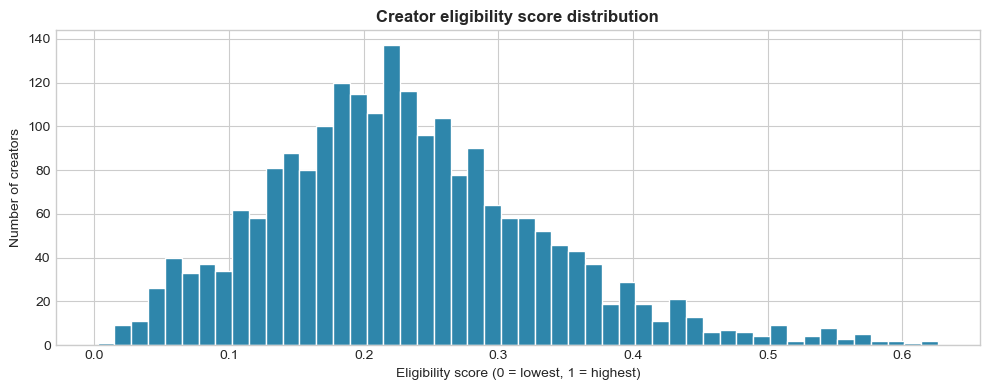

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Components of the eligibility score
# Each component normalized 0–1, then weighted

score_features = [
    'log_total_views',        # Scale of reach
    'like_rate',              # Content quality
    'comment_rate',           # Community engagement
    'trending_days',          # Consistency / sustained presence
    'total_videos',           # Content volume
    'channel_tenure_days',    # Channel maturity
]

# Fill any missing values
for f in score_features:
    creators[f] = creators[f].fillna(0)

# Normalize each component to 0–1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(creators[score_features])
scaled_df = pd.DataFrame(scaled, columns=[f + '_scaled' for f in score_features])
creators = pd.concat([creators.reset_index(drop=True), scaled_df], axis=1)

# Weighted composite score
# Weights reflect what YPP actually cares about most
WEIGHTS = {
    'log_total_views_scaled':    0.30,   # Views = reach
    'like_rate_scaled':          0.20,   # Quality
    'comment_rate_scaled':       0.15,   # Engagement
    'trending_days_scaled':      0.20,   # Consistency
    'total_videos_scaled':       0.10,   # Output
    'channel_tenure_days_scaled':0.05,   # Maturity
}

creators['eligibility_score'] = sum(
    creators[col] * weight for col, weight in WEIGHTS.items()
)

# Penalty for content health issues
creators['eligibility_score'] = (
    creators['eligibility_score']
    * (1 - creators['content_health_flag'] * 0.15)
).clip(0, 1)

print('Eligibility score distribution:')
print(creators['eligibility_score'].describe().round(4))

# Plot score distribution
plt.figure(figsize=(10, 4))
creators['eligibility_score'].hist(bins=50, color='#2E86AB', edgecolor='white')
plt.title('Creator eligibility score distribution', fontsize=12, fontweight='bold')
plt.xlabel('Eligibility score (0 = lowest, 1 = highest)')
plt.ylabel('Number of creators')
plt.tight_layout()
plt.show()

## 6. EDA — Understanding Creator Segments

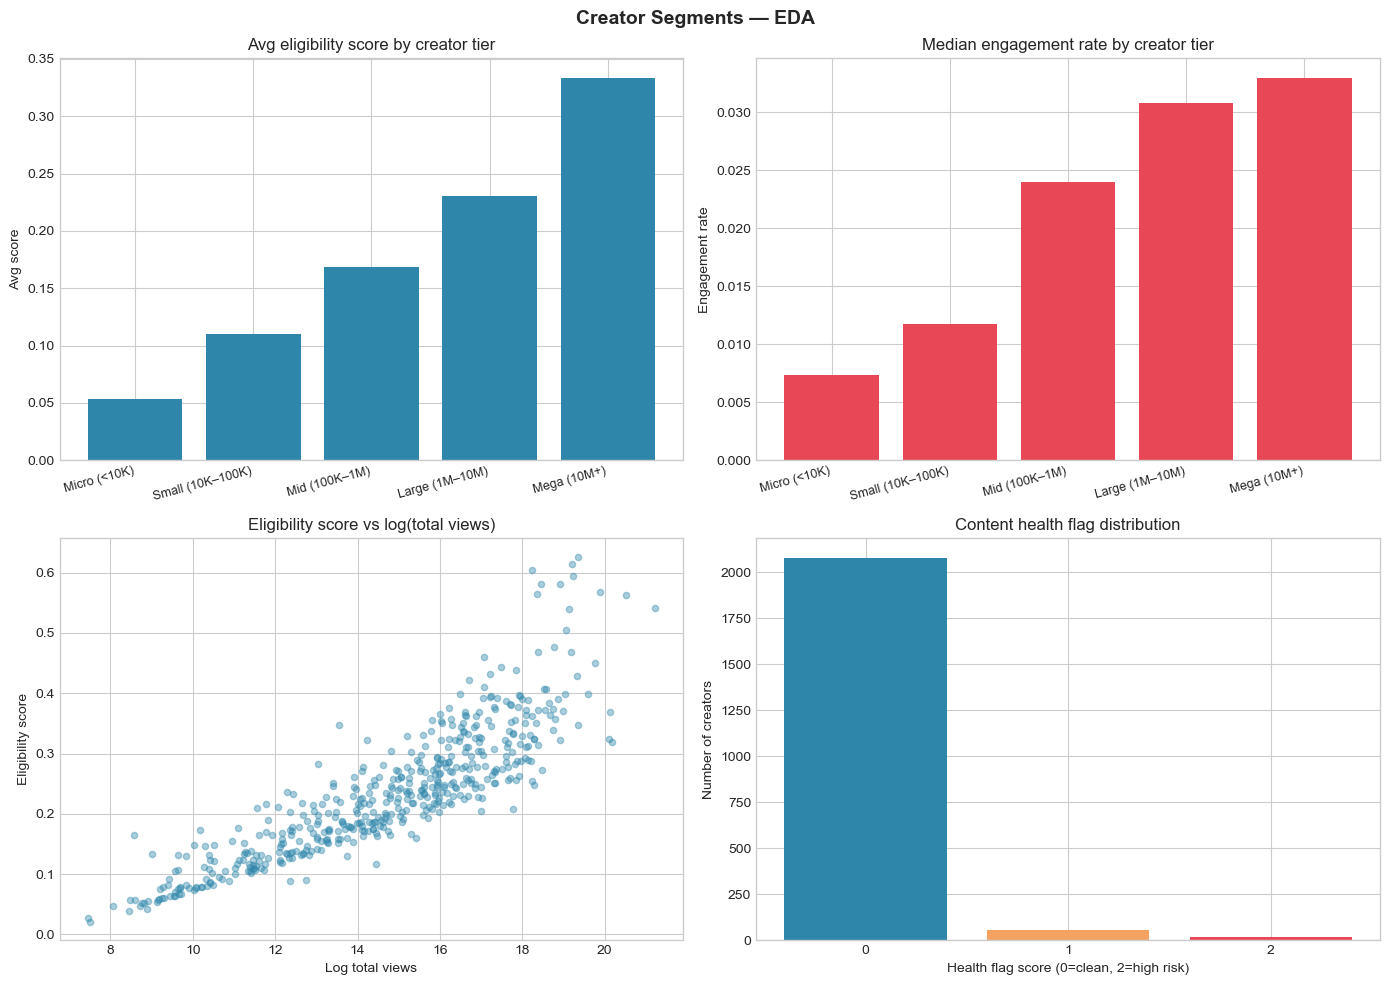

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Creator Segments — EDA', fontsize=14, fontweight='bold')

# 1. Score by tier
ax = axes[0, 0]
tier_scores = creators.groupby('creator_tier', observed=True)['eligibility_score'].mean()
ax.bar(range(len(tier_scores)), tier_scores.values, color='#2E86AB')
ax.set_xticks(range(len(tier_scores)))
ax.set_xticklabels(tier_scores.index, rotation=15, ha='right', fontsize=9)
ax.set_title('Avg eligibility score by creator tier')
ax.set_ylabel('Avg score')

# 2. Engagement rate by tier
ax = axes[0, 1]
tier_engagement = creators.groupby('creator_tier', observed=True)['engagement_rate'].median()
ax.bar(range(len(tier_engagement)), tier_engagement.values, color='#E84855')
ax.set_xticks(range(len(tier_engagement)))
ax.set_xticklabels(tier_engagement.index, rotation=15, ha='right', fontsize=9)
ax.set_title('Median engagement rate by creator tier')
ax.set_ylabel('Engagement rate')

# 3. Score vs views scatter
ax = axes[1, 0]
sample = creators.sample(min(500, len(creators)), random_state=42)
ax.scatter(sample['log_total_views'], sample['eligibility_score'],
           alpha=0.4, color='#2E86AB', s=20)
ax.set_title('Eligibility score vs log(total views)')
ax.set_xlabel('Log total views')
ax.set_ylabel('Eligibility score')

# 4. Content health flag distribution
ax = axes[1, 1]
flag_counts = creators['content_health_flag'].value_counts().sort_index()
ax.bar(flag_counts.index.astype(str), flag_counts.values,
       color=['#2E86AB', '#F4A261', '#E84855'][:len(flag_counts)])
ax.set_title('Content health flag distribution')
ax.set_xlabel('Health flag score (0=clean, 2=high risk)')
ax.set_ylabel('Number of creators')

plt.tight_layout()
plt.show()

In [10]:
# Save creator dataset
creators.to_csv('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/data/processed/creator_features.csv', index=False)
print(f'Saved creator_features.csv — {creators.shape[0]:,} creators, {creators.shape[1]} features')
print('\nNext → 02_policy_simulation.ipynb')

Saved creator_features.csv — 2,153 creators, 34 features

Next → 02_policy_simulation.ipynb
